In [2]:
import pandas as pd
df = pd.read_csv("../src/mars-2014-complete.csv",encoding="latin1", sep=";", low_memory=False)
df = df.drop(columns=[
    'Unnamed: 26',
    'Unnamed: 27',
    'Unnamed: 28',
    'Unnamed: 29'
])
colonnes_numeriques = [
    'puiss_max',
    'conso_urb',
    'conso_exurb',
    'conso_mixte',
    'hc',
    'nox',
    'hcnox',
    'ptcl',
    "co_typ_1"
]

for col in colonnes_numeriques:
    df[col] = df[col] = df[col].replace(',', '.', regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')

df.sample(5)

,lib_mrq,lib_mod_doss,lib_mod,dscom,cnit,tvv,cod_cbr,hybride,puiss_admin_98,puiss_max,...,hc,nox,hcnox,ptcl,masse_ordma_min,masse_ordma_max,champ_v9,date_maj,Carrosserie,gamme
33288,MERCEDES,VITO,VITO,COMBI 113 CDI 4x4,M10MCDVP3722801,639/2KAA73305N2A2D2V39,GO,non,10,100.0,...,NaN,0.228,0.241,0.001,2356,2450,"""715/2007*692/2008EURO5",NaN,MINIBUS,MOY-INFER
34470,MERCEDES,VITO,VITO,COMBI 116 CDI,M10MCDVP371H950,639/2KAA31280N2M3J2S29,GO,non,10,120.0,...,NaN,0.226,0.248,0.001,1976,2075,"""715/2007*692/2008EURO5",NaN,MINIBUS,MOY-INFER
35746,MERCEDES,VITO,VITO,COMBI 116 CDI,M10MCDVP607L646,639/2KAA31305N2M3F1T39,GO,non,10,120.0,...,NaN,0.197,0.216,0.000,2076,2185,"""715/2007*692/2008EURO5",NaN,MINIBUS,MOY-INFER
28877,MERCEDES,VIANO,VIANO,VIANO 3.5 E,M10MCDVP025L840,639/2LAC91280N2A4J7S37,ES,non,18,190.0,...,0.031,0.030,NaN,NaN,2050,2075,"""715/2007*692/2008EURO5",NaN,MINIBUS,MOY-SUPER
33539,MERCEDES,VITO,VITO,COMBI 113 CDI 4x4,M10MCDVP602F451,639/2KAA73280N3A2A2U39,GO,non,9,100.0,...,NaN,0.211,0.220,0.000,2186,2200,"""715/2007*692/2008EURO5",NaN,MINIBUS,MOY-INFER


Test 1 — Variables numériques - enoncé
Test de Pearson & Spearman des variables  vs CO2
Variables analysées: conso_mixte · conso_urb · conso_exurb · puiss_max · puiss_admin_98 · masse_ordma_min

Pearson mesure la corrélation linéaire et suppose une relation proportionnelle. 
Spearman mesure la corrélation de rang, sans hypothèse sur la forme de la relation. 
Comparer les deux coefficients permet de qualifier la relation : si r_Pearson ≈ r_Spearman → relation linéaire ; si r_Spearman > r_Pearson → relation monotone non linéaire. 
H0 : "la variable n'est pas corrélée avec CO2".

=== TEST 1 — Pearson & Spearman ===

conso_mixte
  Pearson  r=+0.9712 | p=0.00e+00
  Spearman r=+0.9867 | p=0.00e+00
  n=55010

conso_urb
  Pearson  r=+0.9094 | p=0.00e+00
  Spearman r=+0.9226 | p=0.00e+00
  n=55001

conso_exurb
  Pearson  r=+0.9677 | p=0.00e+00
  Spearman r=+0.9034 | p=0.00e+00
  n=55001

puiss_max
  Pearson  r=+0.3471 | p=0.00e+00
  Spearman r=+0.1415 | p=6.89e-244
  n=55010

puiss_admin_98
  Pearson  r=+0.4632 | p=0.00e+00
  Spearman r=+0.3868 | p=0.00e+00
  n=55010

masse_ordma_min
  Pearson  r=+0.6437 | p=0.00e+00
  Spearman r=+0.4891 | p=0.00e+00
  n=55010



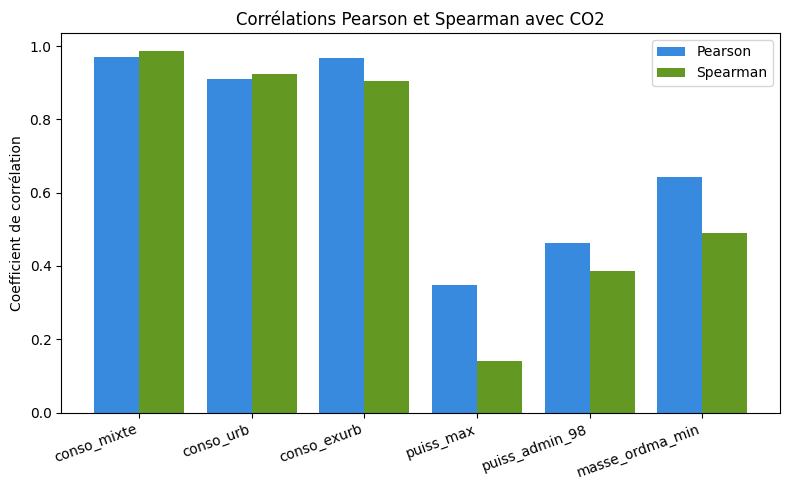

In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt


# ============================================================
# TEST 1 — PEARSON & SPEARMAN (variables numériques vs CO2)
# ============================================================

vars_num = ['conso_mixte', 'conso_urb', 'conso_exurb',
            'puiss_max', 'puiss_admin_98', 'masse_ordma_min']

print("=== TEST 1 — Pearson & Spearman ===\n")

for var in vars_num:
    sous_df = df[['co2', var]].dropna()
    rp, pp = stats.pearsonr(sous_df[var], sous_df['co2'])
    rs, ps = stats.spearmanr(sous_df[var], sous_df['co2'])
    print(f"{var}")
    print(f"  Pearson  r={rp:+.4f} | p={pp:.2e}")
    print(f"  Spearman r={rs:+.4f} | p={ps:.2e}")
    print(f"  n={len(sous_df)}\n")

# Visualisation
plt.figure(figsize=(8, 5))
correlations_pearson  = [stats.pearsonr(df[['co2', v]].dropna()[v],
                                         df[['co2', v]].dropna()['co2'])[0] for v in vars_num]
correlations_spearman = [stats.spearmanr(df[['co2', v]].dropna()[v],
                                          df[['co2', v]].dropna()['co2'])[0] for v in vars_num]

x = np.arange(len(vars_num))
plt.bar(x - 0.2, correlations_pearson,  width=0.4, label='Pearson',  color='#378ADD')
plt.bar(x + 0.2, correlations_spearman, width=0.4, label='Spearman', color='#639922')
plt.xticks(x, vars_num, rotation=20, ha='right')
plt.ylabel('Coefficient de corrélation')
plt.title('Corrélations Pearson et Spearman avec CO2')
plt.legend()
plt.tight_layout()
plt.show()


Test 1 — Variables numériques - Conclusions
Résultats — r Pearson / r Spearman (p ≈ 0 pour toutes)
conso_mixte
P: +0.971 / S: +0.987
conso_exurb
P: +0.968 / S: +0.903
conso_urb
P: +0.909 / S: +0.923
masse_ordma_min
P: +0.644 / S: +0.489
puiss_admin_98
P: +0.463 / S: +0.387
puiss_max
P: +0.347 / S: +0.142
La consommation mixte est quasi-parfaitement corrélée avec CO2 (r=0.97/0.99) — ce n'est pas une surprise physique, car les deux mesures sont liées par une constante chimique. 
Attention : inclure conso_mixte dans un modèle prédictif de CO2 reviendrait à prédire une variable par elle-même, ce qui fausse l'évaluation. 
La masse (r_Pearson=0.64) offre une corrélation modérée mais réellement explicative : un véhicule plus lourd consomme plus d'énergie pour se déplacer. 
La puissance maximale (r_Spearman=0.14) est le prédicteur le plus faible — la puissance déclarée ne reflète pas directement les émissions en usage mixte.

Test 2 — Variable binaire
Test de Student (Welch) — hybride vs non-hybride
Variable : hybride (oui/non) 
Nombre des voitures hybrides - n_hybrides = 389
Nombre de voitures non hybrides - n_non = 54 621
Significatif — p ≈ 0
Pourquoi Student (Welch) ? On compare 2 groupes indépendants sur une variable continue (CO2). 
La variante de Welch (equal_var=False) est préférable à Student classique car elle ne suppose pas l'égalité des variances entre les deux groupes — or les hybrides sont peu nombreux (389) face à 54 621 non-hybrides, ce qui crée un déséquilibre structurel. 
H0 : "les moyennes de CO2 sont identiques entre hybrides et non-hybrides".

=== TEST 2 — Student (Welch) : hybride vs non-hybride ===

Statistique t = -36.7483
p-value       = 3.98e-129
Moyenne hybrides     = 132.8 g/km  (n=389)
Moyenne non-hybrides = 202.2 g/km  (n=54621)
→ On rejette H0 : différence significative de CO2 entre hybrides et non-hybrides


C:\Users\Laura\AppData\Local\Temp\ipykernel_22512\591358026.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='hybride', y='co2', data=df, palette=['#378ADD', '#C0DD97'])


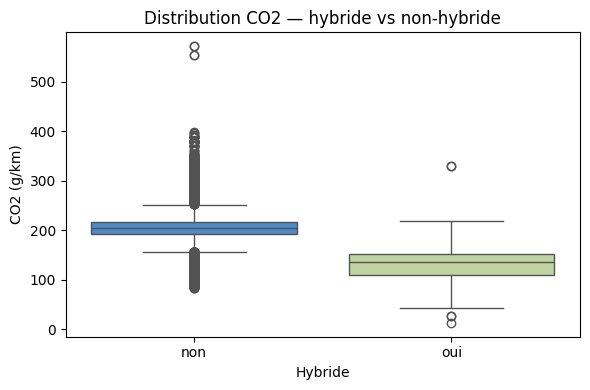

In [4]:
# ============================================================
# TEST 2 — STUDENT (hybride vs non-hybride)
# ============================================================

print("=== TEST 2 — Student (Welch) : hybride vs non-hybride ===\n")

hybrides     = df[df['hybride'] == 'oui']['co2'].dropna()
non_hybrides = df[df['hybride'] == 'non']['co2'].dropna()

stat, p = stats.ttest_ind(hybrides, non_hybrides, equal_var=False)

print(f"Statistique t = {stat:.4f}")
print(f"p-value       = {p:.2e}")
print(f"Moyenne hybrides     = {hybrides.mean():.1f} g/km  (n={len(hybrides)})")
print(f"Moyenne non-hybrides = {non_hybrides.mean():.1f} g/km  (n={len(non_hybrides)})")

if p < 0.05:
    print("→ On rejette H0 : différence significative de CO2 entre hybrides et non-hybrides")
else:
    print("→ On ne rejette pas H0")

# Visualisation
plt.figure(figsize=(6, 4))
sns.boxplot(x='hybride', y='co2', data=df, palette=['#378ADD', '#C0DD97'])
plt.title('Distribution CO2 — hybride vs non-hybride')
plt.xlabel('Hybride')
plt.ylabel('CO2 (g/km)')
plt.tight_layout()
plt.show()

La différence est hautement significative (p ≈ 10⁻¹²⁹). 
Les véhicules hybrides émettent en moyenne 34% de CO2 en moins (132.8 vs 202.2 g/km). 
La statistique t négative confirme que les hybrides sont systématiquement en dessous des non-hybrides. 
Nuance importante : les hybrides ne représentent que 0.7% du dataset (389 véhicules sur 55 000) — leur impact sur un modèle prédictif global sera limité, mais la variable hybride reste un prédicteur pertinent à conserver.

Test 3 — Variable catégorielle (K groupes)
ANOVA — émissions CO2 par type de carburant
Variable : cod_cbr · 6 modalités retenues (effectif > 30)
Significatif — p ≈ 0
Pourquoi l'ANOVA ? On compare les moyennes de CO2 sur plus de 2 groupes indépendants (types de carburant). 
L'ANOVA teste simultanément si au moins un groupe diffère des autres, ce qu'un enchaînement de tests t ne permettrait pas sans inflation du risque d'erreur. 
Justifiée ici par la taille importante de dataset.
H0 : "les moyennes de CO2 sont identiques pour tous les types de carburant".

=== TEST 3 — ANOVA : type de carburant ===

Carburant : EE → 9 observations
  ❌ Groupe ignoré (trop peu d'observations)
Carburant : EH → 298 observations
  ✅ Groupe retenu
Carburant : EL → 0 observations
  ❌ Groupe ignoré (trop peu d'observations)
Carburant : ES → 5169 observations
  ✅ Groupe retenu
Carburant : ES/GN → 32 observations
  ✅ Groupe retenu
Carburant : ES/GP → 23 observations
  ❌ Groupe ignoré (trop peu d'observations)
Carburant : FE → 10 observations
  ❌ Groupe ignoré (trop peu d'observations)
Carburant : GH → 81 observations
  ✅ Groupe retenu
Carburant : GL → 1 observations
  ❌ Groupe ignoré (trop peu d'observations)
Carburant : GN → 21 observations
  ❌ Groupe ignoré (trop peu d'observations)
Carburant : GN/ES → 32 observations
  ✅ Groupe retenu
Carburant : GO → 49311 observations
  ✅ Groupe retenu
Carburant : GP/ES → 23 observations
  ❌ Groupe ignoré (trop peu d'observations)

Statistique F = 326.66
p-value       = 0.00e+00
→ On rejette H0 : au moins un carburant a une m

C:\Users\Laura\AppData\Local\Temp\ipykernel_22512\2929909599.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='cod_cbr', y='co2', data=df_cbr, palette='Blues')


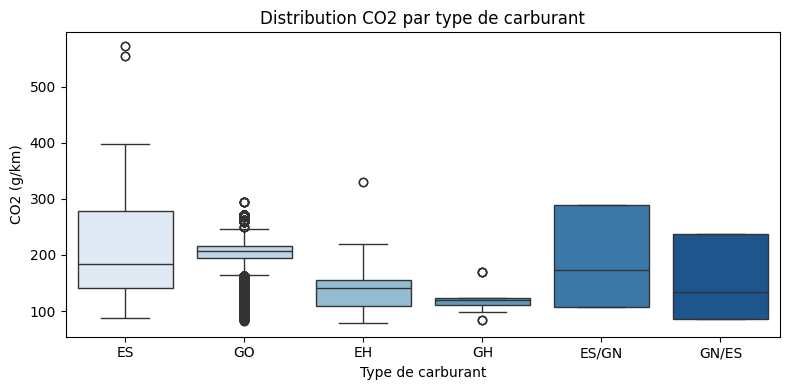

In [5]:
# ============================================================
# TEST 3 — ANOVA : type de carburant (cod_cbr)
# ============================================================

print("=== TEST 3 — ANOVA : type de carburant ===\n")

groupes_par_carburant = df.groupby('cod_cbr')

groupes = []

for nom_carburant, sous_df in groupes_par_carburant:
    valeurs_co2    = sous_df['co2'].dropna().values
    nb_observations = len(valeurs_co2)

    print(f"Carburant : {nom_carburant} → {nb_observations} observations")

    if nb_observations > 30:
        groupes.append(valeurs_co2)
        print(f"  ✅ Groupe retenu")
    else:
        print(f"  ❌ Groupe ignoré (trop peu d'observations)")

stat, p = stats.f_oneway(*groupes)

print(f"\nStatistique F = {stat:.2f}")
print(f"p-value       = {p:.2e}")

if p < 0.05:
    print("→ On rejette H0 : au moins un carburant a une moyenne de CO2 différente")
else:
    print("→ On ne rejette pas H0")

print("\nMoyennes CO2 par carburant :")
print(df.groupby('cod_cbr')['co2'].agg(['mean', 'median', 'count'])
        .sort_values('mean').round(1))

# Visualisation
carburants_retenus = [k for k, g in df.groupby('cod_cbr')
                      if g['co2'].dropna().count() > 30]
df_cbr = df[df['cod_cbr'].isin(carburants_retenus)]

plt.figure(figsize=(8, 4))
sns.boxplot(x='cod_cbr', y='co2', data=df_cbr, palette='Blues')
plt.title('Distribution CO2 par type de carburant')
plt.xlabel('Type de carburant')
plt.ylabel('CO2 (g/km)')
plt.tight_layout()
plt.show()


L'ANOVA rejette H0 avec une force statistique extrême (F=326.66, p≈0) — le type de carburant est un déterminant majeur des émissions. 
Les hybrides (GH, EH) se distinguent nettement avec 30 à 40% d'émissions en moins. 
Le diesel (GO, 202 g/km) dépasse légèrement l'essence (ES, 203 g/km) — résultat contre-intuitif qui s'explique par le profil des véhicules : le diesel équipe principalement des véhicules plus grands et plus lourds dans ce dataset. 
Cette variable est un candidat solide pour la modélisation.

Test 4 — Variable catégorielle (K groupes)
ANOVA — émissions CO2 par type de carrosserie
Variable : Carrosserie · 10 modalités
Significatif — p ≈ 0
Même justification que le test 3. La carrosserie est une variable catégorielle à 10 modalités. 
L'ANOVA permet de tester globalement si la forme du véhicule influence les émissions. 
H0 : "la carrosserie n'a pas d'effet sur les émissions de CO2".

=== TEST 4 — ANOVA : type de carrosserie ===

Statistique F = 4237.58
p-value       = 0.00e+00
→ On rejette H0 : la carrosserie influence significativement les émissions de CO2

Moyennes CO2 par carrosserie :
                      mean  median  count
Carrosserie                              
MINISPACE            125.1   120.0    145
MONOSPACE COMPACT    126.4   120.0    319
COMBISPCACE          141.8   133.5      4
BERLINE              142.1   131.0   4404
COMBISPACE           142.1   139.0    237
BREAK                157.8   144.0   1234
MONOSPACE            160.2   152.0     59
CABRIOLET            176.0   154.0    544
TS TERRAINS/CHEMINS  180.4   165.0   1083
COUPE                206.5   177.5    874
MINIBUS              210.4   209.0  46107


C:\Users\Laura\AppData\Local\Temp\ipykernel_22512\2368750008.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Carrosserie', y='co2', data=df, order=ordre, palette='Greens')


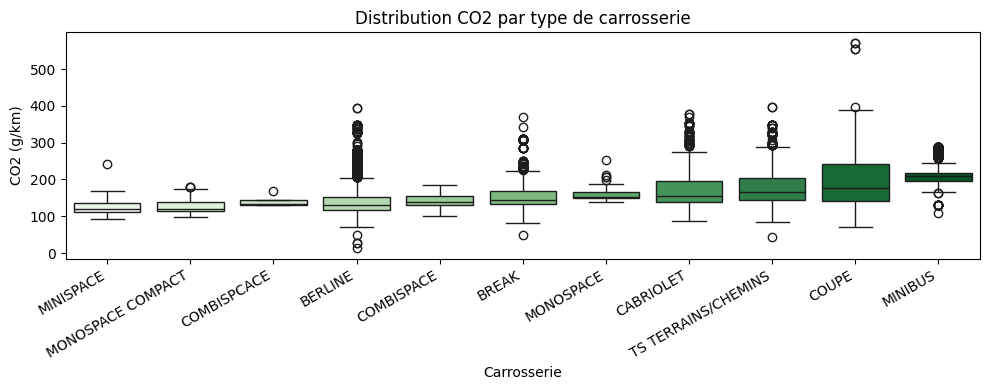

In [6]:
# ============================================================
# TEST 4 — ANOVA : type de carrosserie
# ============================================================

print("=== TEST 4 — ANOVA : type de carrosserie ===\n")

groupes = []

for nom_carrosserie, sous_df in df.groupby('Carrosserie'):
    valeurs_co2     = sous_df['co2'].dropna().values
    nb_observations = len(valeurs_co2)

    if nb_observations > 30:
        groupes.append(valeurs_co2)

stat, p = stats.f_oneway(*groupes)

print(f"Statistique F = {stat:.2f}")
print(f"p-value       = {p:.2e}")

if p < 0.05:
    print("→ On rejette H0 : la carrosserie influence significativement les émissions de CO2")
else:
    print("→ On ne rejette pas H0")

print("\nMoyennes CO2 par carrosserie :")
print(df.groupby('Carrosserie')['co2'].agg(['mean', 'median', 'count'])
        .sort_values('mean').round(1))

# Visualisation
plt.figure(figsize=(10, 4))
ordre = df.groupby('Carrosserie')['co2'].mean().sort_values().index
sns.boxplot(x='Carrosserie', y='co2', data=df, order=ordre, palette='Greens')
plt.title('Distribution CO2 par type de carrosserie')
plt.xlabel('Carrosserie')
plt.ylabel('CO2 (g/km)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


La carrosserie est le test qui affiche le F le plus élevé (4237), signe d'une discrimination très forte entre groupes. 
La hiérarchie est cohérente avec la physique : les véhicules compacts (minispace, 125 g/km) ont une meilleure aérodynamique et une masse plus faible, tandis que les coupés et minibus (205-210 g/km) cumulent masse élevée et motorisations puissantes. 
À noter que le minibus dépasse le coupé, ce qui reflète le poids et la consommation liés au gabarit, malgré des moteurs moins sportifs.

Test 5 — Variable catégorielle (K groupes)
ANOVA — émissions CO2 par gamme commerciale
Variable : gamme · 7 modalités
Significatif — p ≈ 0
Même justification que les tests 3 et 4. La gamme est une segmentation marketing (économique → luxe). L'ANOVA teste si le positionnement commercial du véhicule a un effet réel sur ses émissions. H0 : "la gamme n'influe pas sur les émissions de CO2".

=== TEST 5 — ANOVA : gamme commerciale ===

Statistique F = 2536.21
p-value       = 0.00e+00
→ On rejette H0 : la gamme commerciale influence significativement les émissions de CO2

Moyennes CO2 par gamme :
                 mean  median  count
gamme                               
ECONOMIQUE      116.3   114.0    244
INFERIEURE      125.0   124.0   1071
SUPERIEURE      152.3   140.0   1513
LUXE            186.9   164.0   3593
MOY-INFERIEURE  191.1   192.0     56
MOY-INFER       205.5   208.0  33435
MOY-SUPER       208.6   203.0  15098


C:\Users\Laura\AppData\Local\Temp\ipykernel_22512\3993640128.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='gamme', y='co2', data=df, order=ordre, palette='Oranges')


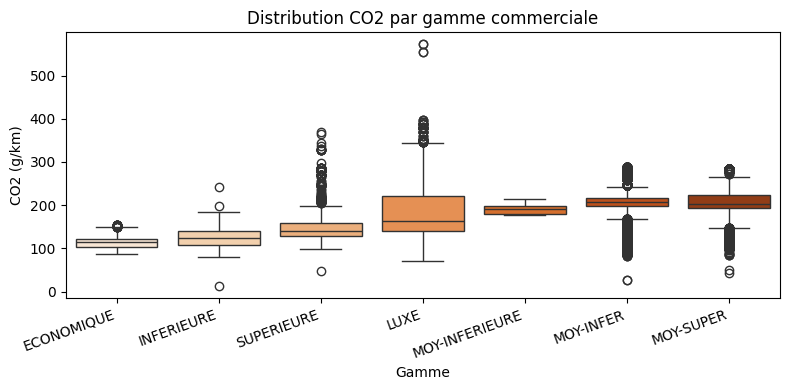

In [7]:
# ============================================================
# TEST 5 — ANOVA : gamme commerciale
# ============================================================

print("=== TEST 5 — ANOVA : gamme commerciale ===\n")

groupes = []

for nom_gamme, sous_df in df.groupby('gamme'):
    valeurs_co2     = sous_df['co2'].dropna().values
    nb_observations = len(valeurs_co2)

    if nb_observations > 30:
        groupes.append(valeurs_co2)

stat, p = stats.f_oneway(*groupes)

print(f"Statistique F = {stat:.2f}")
print(f"p-value       = {p:.2e}")

if p < 0.05:
    print("→ On rejette H0 : la gamme commerciale influence significativement les émissions de CO2")
else:
    print("→ On ne rejette pas H0")

print("\nMoyennes CO2 par gamme :")
print(df.groupby('gamme')['co2'].agg(['mean', 'median', 'count'])
        .sort_values('mean').round(1))

# Visualisation
plt.figure(figsize=(8, 4))
ordre = df.groupby('gamme')['co2'].mean().sort_values().index
sns.boxplot(x='gamme', y='co2', data=df, order=ordre, palette='Oranges')
plt.title('Distribution CO2 par gamme commerciale')
plt.xlabel('Gamme')
plt.ylabel('CO2 (g/km)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

Résultat contre-intuitif mais explicable : les gammes "moy-infer" et "moy-super" émettent davantage que la gamme "luxe" (205-208 vs 186 g/km). 
En 2014, les constructeurs premium (BMW, Mercedes, Lexus) investissaient massivement dans l'hybridation et les technologies de dépollution — technologies absentes des gammes intermédiaires à budget contraint. Les véhicules économiques (116 g/km) bénéficient d'une conception orientée rendement dès l'origine. 
Ce résultat illustre un biais de Simpson à surveiller dans la modélisation.

Test 6 — Relations entre variables qualitatives
Khi-deux — indépendance entre variables catégorielles
3 croisements : hybride×gamme · cod_cbr×Carrosserie · cod_cbr×gamme

Pourquoi le Khi-deux ? C'est le seul test de la liste qui travaille sur deux variables qualitatives sans impliquer CO2. 
Il teste si la distribution d'une variable catégorielle est indépendante d'une autre. 
Cela permet de détecter des confusions structurelles dans le dataset : si carburant et gamme sont liés, alors un modèle qui utilise les deux risque de capturer le même signal deux fois. 
H0 : "les deux variables sont indépendantes".

=== TEST 6 — Khi-deux : indépendance entre variables catégorielles ===

Hybride × Gamme
  χ² = 3131.44 | ddl = 6 | p = 0.00e+00
  → On rejette H0 : hybride et gamme sont dépendantes

Carburant × Carrosserie
  χ² = 25817.29 | ddl = 120 | p = 0.00e+00
  → On rejette H0 : cod_cbr et Carrosserie sont dépendantes

Carburant × Gamme
  χ² = 23752.50 | ddl = 72 | p = 0.00e+00
  → On rejette H0 : cod_cbr et gamme sont dépendantes



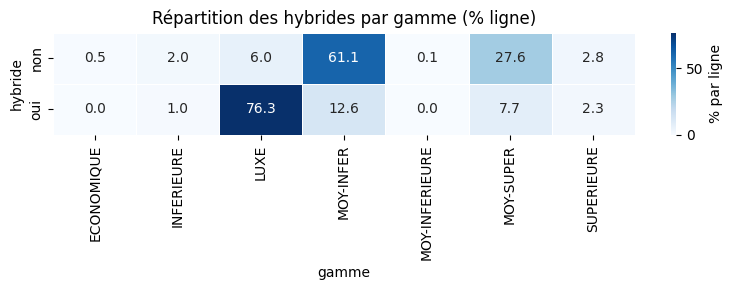

In [8]:
# ============================================================
# TEST 6 — KHI-DEUX (relations entre variables catégorielles)
# ============================================================

print("=== TEST 6 — Khi-deux : indépendance entre variables catégorielles ===\n")

croisements = [
    ('hybride',  'gamme',       'Hybride × Gamme'),
    ('cod_cbr',  'Carrosserie', 'Carburant × Carrosserie'),
    ('cod_cbr',  'gamme',       'Carburant × Gamme'),
]

for var1, var2, label in croisements:
    tableau      = pd.crosstab(df[var1], df[var2])
    chi2, p, dof, expected = stats.chi2_contingency(tableau)

    print(f"{label}")
    print(f"  χ² = {chi2:.2f} | ddl = {dof} | p = {p:.2e}")

    if p < 0.05:
        print(f"  → On rejette H0 : {var1} et {var2} sont dépendantes\n")
    else:
        print(f"  → On ne rejette pas H0 : {var1} et {var2} sont indépendantes\n")

# Visualisation — heatmap hybride x gamme
plt.figure(figsize=(8, 3))
tableau_pct = pd.crosstab(df['hybride'], df['gamme'], normalize='index') * 100
sns.heatmap(tableau_pct, annot=True, fmt='.1f', cmap='Blues',
            linewidths=0.5, cbar_kws={'label': '% par ligne'})
plt.title('Répartition des hybrides par gamme (% ligne)')
plt.tight_layout()
plt.show()

Les trois croisements rejettent l'indépendance avec une force extrême. 
Concrètement : les hybrides se concentrent dans la gamme luxe (297 hybrides en luxe sur 389 au total, soit 76%) — la technologie hybride était en 2014 réservée aux segments premium. 
Le type de carburant est fortement lié à la carrosserie (χ²=25817) : le diesel équipe massivement les minibus et 4x4, l'essence les berlines et coupés. 
Ces dépendances entre variables explicatives sont un signal d'alerte pour la modélisation : elles indiquent une multicolinéarité structurelle entre cod_cbr, Carrosserie et gamme, qui devra être traitée (sélection de variables, ACP ou régularisation).